# 1) Setup & Environment
This cell installs dependencies, mounts Google Drive, and creates fast local directories under `/content/local_data/` so all intermediate data processing avoids Drive I/O bottlenecks.

In [ ]:
import os
import gc
import random
import numpy as np

# Reproducibility for sampling/splitting
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Install required packages
!pip -q install datasets transformers accelerate matplotlib seaborn

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# Mount Google Drive only for final model persistence
drive.mount('/content/drive', force_remount=True)

# Fast local storage for intermediate dataset artifacts
LOCAL_DATA_DIR = '/content/local_data'
TOKENIZED_DATA_DIR = os.path.join(LOCAL_DATA_DIR, 'tinystories_tokenized_pythia70m')
LOCAL_OUTPUT_DIR = os.path.join(LOCAL_DATA_DIR, 'pythia70m_tinystories_outputs')
FINAL_DRIVE_DIR = '/content/drive/MyDrive/pythia70m_tinystories_final'

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_DRIVE_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))

Mounted at /content/drive
Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM (GB): 39.49


# 2) Tokenizer Pivot & Data Prep
This cell loads the native `EleutherAI/pythia-70m` tokenizer, enforces `pad_token = eos_token`, tokenizes TinyStories with `max_length=512`, and caches the processed dataset to local disk for faster reloads.

In [ ]:
from datasets import load_dataset, load_from_disk
from transformers import AutoTokenizer

MODEL_NAME = 'EleutherAI/pythia-70m'
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Tokenizer loaded:', MODEL_NAME)
print('Pad token:', tokenizer.pad_token, '| EOS token:', tokenizer.eos_token)

# Reuse local tokenized artifacts when available to avoid repeated preprocessing
if os.path.exists(TOKENIZED_DATA_DIR):
    tokenized_dataset = load_from_disk(TOKENIZED_DATA_DIR)
    print('Loaded tokenized dataset from local disk:', TOKENIZED_DATA_DIR)
else:
    raw_dataset = load_dataset('roneneldan/TinyStories')
    print(raw_dataset)

    # Identify text column robustly (TinyStories usually uses 'text')
    train_cols = raw_dataset['train'].column_names
    text_col = 'text' if 'text' in train_cols else train_cols[0]
    print('Using text column:', text_col)

    def tokenize_batch(batch):
        return tokenizer(
            batch[text_col],
            truncation=True,
            max_length=MAX_LENGTH
        )

    tokenized_dataset = raw_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=raw_dataset['train'].column_names,
        desc='Tokenizing TinyStories for Pythia-70M'
    )

    tokenized_dataset.save_to_disk(TOKENIZED_DATA_DIR)
    print('Saved tokenized dataset to local fast storage:', TOKENIZED_DATA_DIR)

print(tokenized_dataset)

Tokenizer loaded: EleutherAI/pythia-70m
Pad token: <|padding|> | EOS token: <|endoftext|>
Loaded tokenized dataset from local disk: /content/local_data/tinystories_tokenized_pythia70m
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 21990
    })
})


# 3) Gentle Fine-Tuning
This cell configures low-learning-rate fine-tuning (`5e-5`) with cosine decay and warmup, evaluates every fixed number of steps, applies early stopping, and saves only the final model/tokenizer to Google Drive.

In [ ]:
from transformers import (
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# Resolve train/validation splits robustly
train_split = 'train'
if 'validation' in tokenized_dataset:
    eval_split = 'validation'
elif 'valid' in tokenized_dataset:
    eval_split = 'valid'
elif 'test' in tokenized_dataset:
    eval_split = 'test'
else:
    # Fallback: create a small validation split from train
    split_ds = tokenized_dataset['train'].train_test_split(test_size=0.01, seed=42)
    tokenized_dataset = {'train': split_ds['train'], 'validation': split_ds['test']}
    eval_split = 'validation'

print('Train split:', train_split)
print('Eval split:', eval_split)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
model.config.pad_token_id = tokenizer.pad_token_id

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Use bf16 on Ampere+ GPUs (e.g., A100), else fallback to fp16 on older CUDA GPUs
# Disabling mixed precision explicitly as per subtask instructions
# use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
# use_fp16 = torch.cuda.is_available() and not use_bf16
use_bf16 = False
use_fp16 = False

training_args = TrainingArguments(
    output_dir=LOCAL_OUTPUT_DIR,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    logging_steps=500,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,          # DECREASED: 5e-5 was just a tiny bit too aggressive for Pythia
    max_grad_norm=0.3,           # shock absorber. It prevents NaN explosions.
    weight_decay=0.05,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    gradient_accumulation_steps=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    logging_dir=os.path.join(LOCAL_OUTPUT_DIR, 'logs'),
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

train_result = trainer.train()
eval_result = trainer.evaluate()

print('Training complete.')
print('Final train metrics:', train_result.metrics)
print('Final eval metrics:', eval_result)

# Save final model/tokenizer to Google Drive (only final artifacts)
trainer.save_model(FINAL_DRIVE_DIR)
tokenizer.save_pretrained(FINAL_DRIVE_DIR)
print('Saved final model and tokenizer to:', FINAL_DRIVE_DIR)

# Clear memory after training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Memory cleanup done.')

Train split: train
Eval split: validation


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss,Validation Loss
500,2.511396,2.332311
1000,2.250185,2.203755
1500,2.147783,2.130962
2000,2.089687,2.076429
2500,2.041040,2.034452
3000,1.998750,1.998851
3500,1.967769,1.969758
4000,1.943912,1.944648
4500,1.927076,1.923404
5000,1.897740,1.905370


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Final train metrics: {'train_runtime': 32773.9919, 'train_samples_per_second': 64.677, 'train_steps_per_second': 4.042, 'total_flos': 2.1656658047891866e+17, 'train_loss': 1.5136958425503177, 'epoch': 1.0}
Final eval metrics: {'eval_loss': 1.4302728176116943, 'eval_runtime': 55.1869, 'eval_samples_per_second': 398.464, 'eval_steps_per_second': 49.813, 'epoch': 1.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final model and tokenizer to: /content/drive/MyDrive/pythia70m_tinystories_final
Memory cleanup done.


# 4) Native Loss Visualizations
This cell extracts train/eval loss directly from `trainer.state.log_history` and plots both curves with matplotlib/seaborn for an inline convergence view.

✅ Found active 'trainer' in memory. Loading log history...


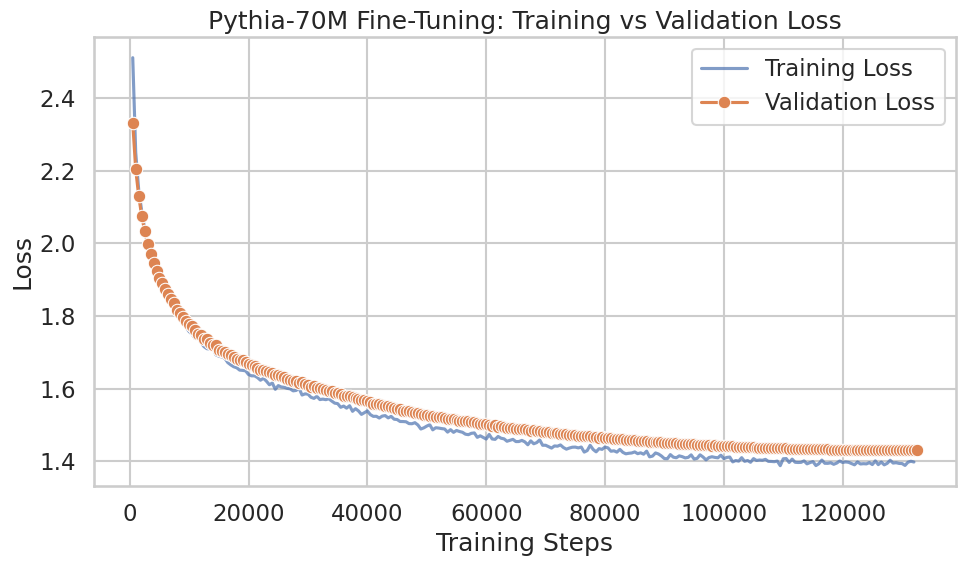

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
520,1.388136,4.635478,1.226034e-08,0.985036,130500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
521,NaN,NaN,NaN,0.985036,130500,1.430282,55.0459,399.485,49.940,NaN,NaN,NaN,NaN,NaN
522,1.397127,5.453510,6.860034e-09,0.988810,131000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,0.988810,131000,1.430275,55.0737,399.283,49.915,NaN,NaN,NaN,NaN,NaN
524,1.399644,4.244508,3.016313e-09,0.992584,131500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
525,NaN,NaN,NaN,0.992584,131500,1.430274,55.0897,399.167,49.900,NaN,NaN,NaN,NaN,NaN
526,1.397538,4.578700,7.297827e-10,0.996358,132000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527,NaN,NaN,NaN,0.996358,132000,1.430273,55.1156,398.979,49.877,NaN,NaN,NaN,NaN,NaN
528,NaN,NaN,NaN,1.000000,132483,NaN,NaN,NaN,NaN,32773.9919,64.677,4.042,2.165666e+17,1.513696
529,NaN,NaN,NaN,1.000000,132483,1.430273,55.1869,398.464,49.813,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

log_history = None
FINAL_DRIVE_DIR = '/content/drive/MyDrive/pythia70m_tinystories_final'

# 1. First Priority: Check if the 'trainer' object exists in active memory
if 'trainer' in globals() and hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    print("✅ Found active 'trainer' in memory. Loading log history...")
    log_history = trainer.state.log_history

# 2. Second Priority: Fallback to the saved JSON file on Google Drive
else:
    state_path = os.path.join(FINAL_DRIVE_DIR, "trainer_state.json")
    if os.path.exists(state_path):
        print(f"🔄 'trainer' not in memory. Loading from saved state: {state_path}")
        with open(state_path, "r") as f:
            log_history = json.load(f).get("log_history", [])

    # 3. Third Priority: Graceful failure
    else:
        print("❌ Error: Could not find 'trainer' in memory OR 'trainer_state.json' on Drive.")
        print(f"Expected path: {state_path}")
        print("Please ensure your training run completed and saved successfully.")

# Execute plotting only if logs were successfully retrieved
if log_history:
    log_df = pd.DataFrame(log_history)

    # Guard against missing columns in short runs
    train_loss_df = log_df[log_df['loss'].notna()][['step', 'loss']].copy() if 'loss' in log_df.columns else pd.DataFrame(columns=['step', 'loss'])
    eval_loss_df = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss']].copy() if 'eval_loss' in log_df.columns else pd.DataFrame(columns=['step', 'eval_loss'])

    plt.figure(figsize=(10, 6))
    if not train_loss_df.empty:
        # Note: If you have thousands of steps, marker='o' might make the line look very thick.
        sns.lineplot(data=train_loss_df, x='step', y='loss', label='Training Loss', alpha=0.7)
    if not eval_loss_df.empty:
        sns.lineplot(data=eval_loss_df, x='step', y='eval_loss', marker='o', label='Validation Loss')

    plt.title('Pythia-70M Fine-Tuning: Training vs Validation Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(log_df.tail(10))

# 5) Domain Adherence (OOV) & Generation
This cell builds a TinyStories-derived allowed vocabulary from 50,000 sampled stories, generates 20 continuations from the fine-tuned model, and computes the OOV error rate.

In [ ]:
import re
import torch
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

# FINAL_DRIVE_DIR = '/content/drive/MyDrive/pythia70m_tinystories_final'

# Reload raw TinyStories for vocabulary extraction
raw_dataset_for_vocab = load_dataset('roneneldan/TinyStories')
train_cols = raw_dataset_for_vocab['train'].column_names
text_col = 'text' if 'text' in train_cols else train_cols[0]

VOCAB_SAMPLE_SIZE = 50_000
available = len(raw_dataset_for_vocab['train'])
sample_size = min(VOCAB_SAMPLE_SIZE, available)

# Shuffle before sampling to reduce ordering bias in vocabulary coverage
vocab_sample = raw_dataset_for_vocab['train'].shuffle(seed=42).select(range(sample_size))

word_pattern = re.compile(r"[a-z]+")
allowed_vocab = set()
for text in vocab_sample[text_col]:
    allowed_vocab.update(word_pattern.findall(text.lower()))

print(f'Allowed vocabulary size from {sample_size:,} stories: {len(allowed_vocab):,}')

# Generation setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AutoModelForCausalLM.from_pretrained(FINAL_DRIVE_DIR, torch_dtype=torch.float32).to(device)
tokenizer = AutoTokenizer.from_pretrained(FINAL_DRIVE_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

prompts = [
    'Once upon a time in a small forest,',
    'Lily opened the old wooden door and',
    'Tom and his little brother found a map that',
    'On a rainy afternoon, the cat decided to',
    'The tiny dragon looked at the moon and',
    'Mia packed her red bag before she',
    'At the edge of the village, there was a tree that',
    'Ben whispered to his friend, Suddenly,',
    'The robot in the classroom learned to',
    'Grandpa smiled and pointed to the sky where',
    'When the bell rang, everyone saw that',
    'Nora put the seed in the soil and',
    'The little boat drifted gently until',
    'After dinner, Sam heard a soft sound from',
    'Inside the library, a secret note said',
    'The puppy carried a blue ribbon because',
    'One morning, the sun did not rise until',
    'At the science fair, Zoe showed everyone how',
    'A friendly giant knocked on the gate and',
    'Before going to sleep, Ava wrote that'
]

generated_texts = []
for i, prompt in enumerate(prompts, start=1):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.9,
            do_sample=True,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )
    gen_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_texts.append(gen_text)
    print(f'--- Story {i} ---')
    print(gen_text)
    print()

# OOV computation against TinyStories-derived allowed vocabulary
all_generated_words = []
for story in generated_texts:
    all_generated_words.extend(word_pattern.findall(story.lower()))

total_words = len(all_generated_words)
oov_words = [w for w in all_generated_words if w not in allowed_vocab]
oov_count = len(oov_words)
oov_rate = (oov_count / total_words) if total_words > 0 else 0.0

print(f'Total generated words: {total_words:,}')
print(f'OOV words: {oov_count:,}')
print(f'OOV Error Rate (Pythia-70M fine-tuned): {oov_rate * 100:.4f}%')

if oov_count > 0:
    print('Most common OOV words:')
    for word, cnt in Counter(oov_words).most_common(20):
        print(f'  {word}: {cnt}')

Allowed vocabulary size from 50,000 stories: 14,197


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

--- Story 1 ---
Once upon a time in a small forest, there was a little girl named Lucy. She was very brave and loved exploring the world around her.

One day, she decided to go on an adventure and ventured into the forest. She walked and walked, and eventually she found a big bush. She wondered what she could find. 

Lucy was very excited. She ran over and started to search. She looked up and down and

--- Story 2 ---
Lily opened the old wooden door and smiled. She felt happy. She had a secret to open.

She looked inside and saw a lot of things. There was a table, a chair, a chair, a chair. She wondered what it was for.

She took a big bite of the table and tried to chew it. It was bitter, but she liked it. She made a funny face and tried to

--- Story 3 ---
Tom and his little brother found a map that Tom's dad had read to him. Tom was very happy and ran to find his dad. He wanted to show him where the map could be. He used his toy truck to make the map into different things. He preten

# 6) OOV Comparison Chart
This final cell compares the fine-tuned Pythia OOV rate against the hardcoded custom 91.7M baseline (0.5%) using a simple labeled bar chart. Still need to implement the actual optimised model instead of the hardcoded baseline.

Using Pythia model: c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\pythia70m_tinystories_final-20260402T062712Z-1-001\pythia70m_tinystories_final
Using Baseline model: c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\finalised_best_model-20260402T062713Z-1-001\finalised_best_model


README.md: 0.00B [00:00, ?B/s]

c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ngwei\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Fine-tuned Pythia-70M: total words=1,401, oov words=1, oov rate=0.0714%


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Optimized Baseline 91.7M: total words=1,466, oov words=1, oov rate=0.0682%


C:\Users\ngwei\AppData\Local\Temp\ipykernel_42844\575998628.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparison_df, x='Model', y='OOV Rate (%)', palette='Set2')


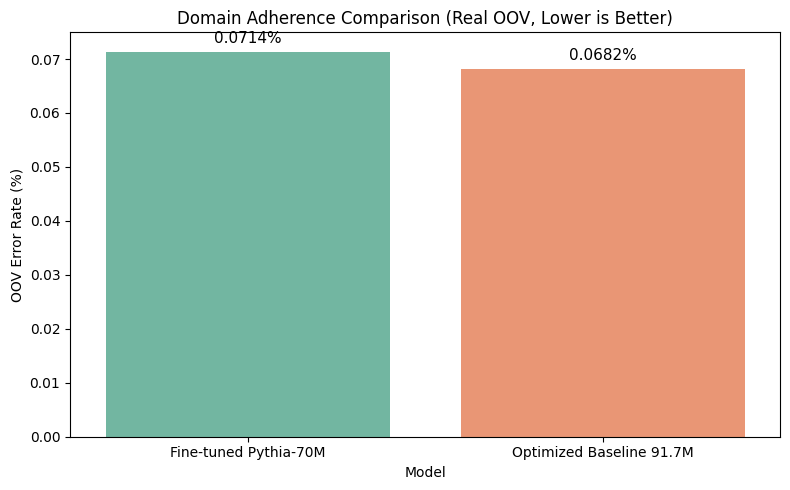

Saved OOV comparison to: c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\oov_comparison.json


,Model,OOV Rate (%)
0,Fine-tuned Pythia-70M,0.071378
1,Optimized Baseline 91.7M,0.068213


In [5]:
from pathlib import Path
import re
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

notebook_dir = Path.cwd()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

pythia_candidates = [
    notebook_dir / 'pythia70m_tinystories_final-20260402T062712Z-1-001' / 'pythia70m_tinystories_final',
    notebook_dir / 'pythia70m_tinystories_final',
    notebook_dir / 'models (1)' / 'runs' / 'finalised_best_model' / 'final_model',
]

baseline_candidates = [
    notebook_dir / 'finalised_best_model-20260402T062713Z-1-001' / 'finalised_best_model',
    notebook_dir / 'models (1)' / 'runs' / 'gptneo_33M_replicated' / 'final_model',
    notebook_dir / 'models (1)' / 'runs' / 'finalised_best_model' / 'final_model',
]

def resolve_model_path(candidates, label):
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f'{label} model path not found. Checked: {candidates}')
    return path

PYTHIA_PATH = resolve_model_path(pythia_candidates, 'Pythia')
BASELINE_PATH = resolve_model_path(baseline_candidates, 'Baseline')

print('Using Pythia model:', PYTHIA_PATH)
print('Using Baseline model:', BASELINE_PATH)

# Rebuild allowed TinyStories vocabulary if not already available in this kernel
if 'allowed_vocab' not in globals() or not allowed_vocab:
    raw_dataset_for_vocab = load_dataset('roneneldan/TinyStories')
    train_cols = raw_dataset_for_vocab['train'].column_names
    text_col = 'text' if 'text' in train_cols else train_cols[0]

    VOCAB_SAMPLE_SIZE = 50_000
    available = len(raw_dataset_for_vocab['train'])
    sample_size = min(VOCAB_SAMPLE_SIZE, available)

    vocab_sample = raw_dataset_for_vocab['train'].shuffle(seed=42).select(range(sample_size))
    word_pattern = re.compile(r'[a-z]+')
    allowed_vocab = set()
    for text in vocab_sample[text_col]:
        allowed_vocab.update(word_pattern.findall(text.lower()))

    print(f'Allowed vocabulary rebuilt from {sample_size:,} stories: {len(allowed_vocab):,}')
else:
    print(f'Using existing allowed vocabulary: {len(allowed_vocab):,} words')
    if 'word_pattern' not in globals():
        word_pattern = re.compile(r'[a-z]+')

prompts = [
    'Once upon a time in a small forest,',
    'Lily opened the old wooden door and',
    'Tom and his little brother found a map that',
    'On a rainy afternoon, the cat decided to',
    'The tiny dragon looked at the moon and',
    'Mia packed her red bag before she',
    'At the edge of the village, there was a tree that',
    'Ben whispered to his friend, Suddenly,',
    'The robot in the classroom learned to',
    'Grandpa smiled and pointed to the sky where',
    'When the bell rang, everyone saw that',
    'Nora put the seed in the soil and',
    'The little boat drifted gently until',
    'After dinner, Sam heard a soft sound from',
    'Inside the library, a secret note said',
    'The puppy carried a blue ribbon because',
    'One morning, the sun did not rise until',
    'At the science fair, Zoe showed everyone how',
    'A friendly giant knocked on the gate and',
    'Before going to sleep, Ava wrote that',
]

def compute_oov_rate(model_path, prompts, label):
    model = AutoModelForCausalLM.from_pretrained(str(model_path), torch_dtype=torch.float32).to(device)
    tokenizer = AutoTokenizer.from_pretrained(str(model_path))
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.eval()

    generated_words = []
    for i, prompt in enumerate(prompts, start=1):
        inputs = tokenizer(prompt, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=80,
                temperature=0.9,
                do_sample=True,
                top_p=0.95,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
            )
        text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        generated_words.extend(word_pattern.findall(text.lower()))

    total_words = len(generated_words)
    oov_words = [w for w in generated_words if w not in allowed_vocab]
    oov_count = len(oov_words)
    oov_rate_local = (oov_count / total_words) if total_words > 0 else 0.0

    print(f'{label}: total words={total_words:,}, oov words={oov_count:,}, oov rate={oov_rate_local * 100:.4f}%')
    return oov_rate_local

pythia_oov_rate = compute_oov_rate(PYTHIA_PATH, prompts, 'Fine-tuned Pythia-70M')
baseline_oov_rate = compute_oov_rate(BASELINE_PATH, prompts, 'Optimized Baseline 91.7M')

comparison_df = pd.DataFrame({
    'Model': ['Fine-tuned Pythia-70M', 'Optimized Baseline 91.7M'],
    'OOV Rate (%)': [pythia_oov_rate * 100, baseline_oov_rate * 100],
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparison_df, x='Model', y='OOV Rate (%)', palette='Set2')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.4f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points',
    )

plt.title('Domain Adherence Comparison (Real OOV, Lower is Better)')
plt.xlabel('Model')
plt.ylabel('OOV Error Rate (%)')
plt.tight_layout()
plt.show()

oov_output_path = notebook_dir / 'oov_comparison.json'
comparison_df.to_json(oov_output_path, orient='records', indent=2)
print(f'Saved OOV comparison to: {oov_output_path}')

comparison_df

##Evaluation Comparison between Pythia finetuned model and Baseline Optimised model

This cell compares the content of both models using 50 prompts and then using Grok to evalaute the output of the prompts

In [ ]:
# ============ LOCAL SETUP (NO DRIVE NEEDED) ============
# Models and data are in local notebook directory
print("✅ Ready for local Ollama evaluation")
print("Make sure Ollama is running: ollama serve")
print("Note: Update JUDGE_MODEL if using different Ollama models (e.g., 'mistral', 'neural-chat')")

Mounted at /content/drive


In [2]:
# ============================================================
# CELL 1 — Judge Setup, Model Loading, Prompt Fetch
# ============================================================
import os, re, json, time, yaml, torch, requests
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Judge config ─────────────────────────────────────────────
PREFERRED_JUDGE_MODEL = "llama3.1:8b"
N_COMPLETIONS         = 10
MAX_JUDGE_RETRIES     = 3
device                = "cuda" if torch.cuda.is_available() else "cpu"

# ── Endpoint detection (original logic, unchanged) ────────────
def resolve_judge_endpoint():
    candidates = [
        ("ollama", "http://localhost:11434",   "/api/tags",        "/api/generate"),
        ("ollama", "http://127.0.0.1:11434",   "/api/tags",        "/api/generate"),
        ("ollama", "http://localhost:11434",   "/ollama/api/tags", "/ollama/api/generate"),
        ("ollama", "http://127.0.0.1:11434",   "/ollama/api/tags", "/ollama/api/generate"),
        ("openai", "http://localhost:11434",   "/v1/models",       "/v1/chat/completions"),
        ("openai", "http://127.0.0.1:11434",   "/v1/models",       "/v1/chat/completions"),
    ]
    for api_kind, base_url, health_path, gen_path in candidates:
        try:
            r = requests.get(f"{base_url}{health_path}", timeout=5)
            if r.status_code == 200:
                print(f"Judge endpoint detected: {base_url}{health_path} ({api_kind})")
                return {
                    "api_kind":     api_kind,
                    "base_url":     base_url,
                    "health_url":   f"{base_url}{health_path}",
                    "generate_url": f"{base_url}{gen_path}",
                }
        except requests.RequestException:
            pass
    raise RuntimeError(
        "No local judge endpoint found. Run `ollama serve` or start your OpenAI-compatible server."
    )

def resolve_judge_model(judge_api, preferred):
    try:
        health = requests.get(judge_api["health_url"], timeout=10).json()
        if judge_api["api_kind"] == "ollama":
            available = [m.get("name") for m in health.get("models", []) if m.get("name")]
        else:
            available = [m.get("id") for m in health.get("data", []) if m.get("id")]

        if not available:
            print(f"No models listed by endpoint; using configured model: {preferred}")
            return preferred
        if preferred in available:
            print(f"Using configured judge model: {preferred}")
            return preferred
        fallback = available[0]
        print(f"Configured judge model '{preferred}' not found. Falling back to '{fallback}'.")
        return fallback
    except Exception as e:
        print(f"Could not validate judge model list ({e}); using configured model: {preferred}")
        return preferred

JUDGE_API   = resolve_judge_endpoint()
JUDGE_MODEL = resolve_judge_model(JUDGE_API, PREFERRED_JUDGE_MODEL)

# ── Judge eval with retry + robust JSON extraction ────────────
SYSTEM_PROMPT = (
    "You are a strict JSON-only grading assistant. "
    "You NEVER continue stories. You ONLY output a single JSON object. "
    "No prose, no markdown, no explanation — raw JSON only."
)

def build_eval_prompt(prompt, story):
    return (
        "Grade this children's story completion on four criteria, scored 1-10 each.\n\n"
        f"<story_prompt>{prompt}</story_prompt>\n"
        f"<story_completion>{story}</story_completion>\n\n"
        "Reply with ONLY this JSON and absolutely nothing else:\n"
        '{"grammar": <int>, "creativity": <int>, "consistency": <int>, "plot": <int>}'
    )

def extract_json(text):
    """Handle fenced (```json...```), bare ({...}), and embedded JSON."""
    # Strip markdown fences
    fence = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if fence:
        return json.loads(fence.group(1))
    # First {...} block
    brace = re.search(r'\{[^{}]*\}', text, re.DOTALL)
    if brace:
        return json.loads(brace.group())
    raise ValueError(f"No JSON object found in: {text[:300]!r}")

def ollama_eval(prompt, story):
    eval_prompt = build_eval_prompt(prompt, story)
    response    = None

    for attempt in range(1, MAX_JUDGE_RETRIES + 1):
        try:
            if JUDGE_API["api_kind"] == "ollama":
                response = requests.post(
                    JUDGE_API["generate_url"],
                    json={
                        "model":  JUDGE_MODEL,
                        "system": SYSTEM_PROMPT,
                        "prompt": eval_prompt,
                        "stream": False,
                        "options": {"temperature": 0.1, "num_predict": 128},
                    },
                    timeout=60,
                )
                response.raise_for_status()
                raw = response.json().get("response", "")

            else:  # OpenAI-compatible
                response = requests.post(
                    JUDGE_API["generate_url"],
                    json={
                        "model": JUDGE_MODEL,
                        "messages": [
                            {"role": "system", "content": SYSTEM_PROMPT},
                            {"role": "user",   "content": eval_prompt},
                        ],
                        "temperature": 0.1,
                        "max_tokens":  128,
                    },
                    timeout=60,
                )
                response.raise_for_status()
                raw = (
                    response.json()
                    .get("choices", [{}])[0]
                    .get("message", {})
                    .get("content", "")
                )

            scores = extract_json(raw)

            # Validate and cast all required keys
            for key in ("grammar", "creativity", "consistency", "plot"):
                if key not in scores:
                    raise ValueError(f"Missing key '{key}' in: {scores}")
                scores[key] = int(scores[key])

            scores["overall"] = round(
                sum(scores[k] for k in ("grammar", "creativity", "consistency", "plot")) / 4, 2
            )
            return scores

        except (ValueError, json.JSONDecodeError) as e:
            print(f"    ⚠ Judge parse error (attempt {attempt}/{MAX_JUDGE_RETRIES}): {e}")
            if attempt < MAX_JUDGE_RETRIES:
                time.sleep(1)
        except requests.HTTPError as e:
            body = getattr(response, "text", "")[:300]
            print(f"    ⚠ Judge HTTP error (attempt {attempt}/{MAX_JUDGE_RETRIES}): {e} | {body}")
            if attempt < MAX_JUDGE_RETRIES:
                time.sleep(2)

    raise RuntimeError(f"Judge failed after {MAX_JUDGE_RETRIES} attempts.")

# ── Load Pythia model ─────────────────────────────────────────
notebook_dir = Path.cwd()

pythia_candidates = [
    notebook_dir / "pythia70m_tinystories_final",
    notebook_dir / "pythia70m_tinystories_final-20260402T062712Z-1-001" / "pythia70m_tinystories_final",
    notebook_dir / "finalised_best_model-20260402T062713Z-1-001" / "finalised_best_model",
    notebook_dir / "models (1)" / "runs" / "finalised_best_model" / "final_model",
    notebook_dir / "models (1)" / "runs" / "gptneo_33M_replicated" / "final_model",
]
PYTHIA_PATH = next((p for p in pythia_candidates if p.exists()), None)
if PYTHIA_PATH is None:
    print("Available files:", list(notebook_dir.glob("*")))
    raise FileNotFoundError("Pythia model directory not found.")

pythia_model = AutoModelForCausalLM.from_pretrained(str(PYTHIA_PATH)).to(device)
pythia_tok   = AutoTokenizer.from_pretrained(str(PYTHIA_PATH))
if pythia_tok.pad_token is None:
    pythia_tok.pad_token = pythia_tok.eos_token
pythia_model.eval()
print(f"Pythia-70M loaded from {PYTHIA_PATH} ✅")

# ── Load Baseline model ───────────────────────────────────────
baseline_candidates = [
    notebook_dir / "finalised_best_model-20260402T062713Z-1-001" / "finalised_best_model",
    notebook_dir / "models (1)" / "runs" / "finalised_best_model" / "final_model",
    notebook_dir / "models (1)" / "runs" / "gptneo_33M_replicated" / "final_model",
]
BASELINE_PATH = next((p for p in baseline_candidates if p.exists()), None)
if BASELINE_PATH is None:
    print(f"❌ Baseline model not found. Available: {list(notebook_dir.glob('*'))}")
else:
    baseline_model = AutoModelForCausalLM.from_pretrained(str(BASELINE_PATH)).to(device)
    baseline_tok   = AutoTokenizer.from_pretrained(str(BASELINE_PATH))
    if baseline_tok.pad_token is None:
        baseline_tok.pad_token = baseline_tok.eos_token
    baseline_model.eval()
    print(f"Baseline loaded from {BASELINE_PATH} ✅")

# ── Fetch prompts ─────────────────────────────────────────────
def fetch_prompts(limit=50):
    url = (
        "https://huggingface.co/datasets/roneneldan/TinyStories"
        "/resolve/main/Evaluation%20prompts.yaml"
    )
    try:
        data    = yaml.safe_load(requests.get(url, timeout=15).text)
        prompts = [list(p.values())[0] if isinstance(p, dict) else p for p in data]
        return prompts[:limit]
    except Exception as e:
        print(f"Prompt fetch failed ({e}), using fallback prompts.")
        return [
            "Once upon a time there was a little girl",
            "One day a puppy named Max",
        ]

prompts = fetch_prompts(50)
print(f"Loaded {len(prompts)} prompts ✅")
print("\nCell 1 complete — run Cell 2 to start evaluation.")

Judge endpoint detected: http://localhost:11434/api/tags (ollama)
Configured judge model 'llama3.1:8b' not found. Falling back to 'llama3:latest'.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Pythia-70M loaded from c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\pythia70m_tinystories_final-20260402T062712Z-1-001\pythia70m_tinystories_final ✅


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Baseline loaded from c:\Users\ngwei\Documents\Y2T2\AAI3008 Large Language Models\Project\finalised_best_model-20260402T062713Z-1-001\finalised_best_model ✅
Loaded 44 prompts ✅

Cell 1 complete — run Cell 2 to start evaluation.


In [3]:
# ============================================================
# CELL 2 — Story Generation + Evaluation + Save
# ============================================================

def generate_story(model, tokenizer, prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)[len(prompt):].strip()

def evaluate_model(model, tokenizer, model_label):
    """Generate stories, evaluate each with the judge, and collect all results."""
    # Running totals for global averages
    all_scores = {k: [] for k in ("grammar", "creativity", "consistency", "plot", "overall")}

    # Per-prompt detail (scores + raw stories kept separate for saving)
    per_prompt_scores  = []   # metrics only — goes into metrics JSON
    per_prompt_stories = []   # stories only — goes into stories JSON

    for i, prompt in enumerate(prompts):
        print(f"[{model_label}] Prompt {i+1}/{len(prompts)}: '{prompt[:55]}...'")

        prompt_scores  = {k: [] for k in ("grammar", "creativity", "consistency", "plot", "overall")}
        stories_this_prompt = []   # (story_text, scores_dict) pairs
        failed = 0

        for j in range(N_COMPLETIONS):
            story = generate_story(model, tokenizer, prompt)
            try:
                scores = ollama_eval(prompt, story)

                # Store story + its individual scores together
                stories_this_prompt.append({
                    "story":       story,
                    "grammar":     scores["grammar"],
                    "creativity":  scores["creativity"],
                    "consistency": scores["consistency"],
                    "plot":        scores["plot"],
                    "overall":     scores["overall"],
                })

                for k in ("grammar", "creativity", "consistency", "plot", "overall"):
                    prompt_scores[k].append(scores[k])
                    all_scores[k].append(scores[k])

                print(
                    f"  [{j+1}/{N_COMPLETIONS}] "
                    f"grammar={scores['grammar']} creativity={scores['creativity']} "
                    f"consistency={scores['consistency']} plot={scores['plot']}"
                )
            except RuntimeError as e:
                failed += 1
                print(f"  ✗ Completion {j+1} skipped after retries: {e}")

        if prompt_scores["grammar"]:
            avgs = {k: round(sum(v) / len(v), 2) for k, v in prompt_scores.items()}
            print(
                f"  → avg: grammar={avgs['grammar']} creativity={avgs['creativity']} "
                f"consistency={avgs['consistency']} plot={avgs['plot']} "
                f"overall={avgs['overall']}  (failed={failed})\n"
            )

            # Metrics record (no story text)
            per_prompt_scores.append({
                "prompt":          prompt,
                "avg_grammar":     avgs["grammar"],
                "avg_creativity":  avgs["creativity"],
                "avg_consistency": avgs["consistency"],
                "avg_plot":        avgs["plot"],
                "avg_overall":     avgs["overall"],
                "n_completed":     len(prompt_scores["grammar"]),
                "n_failed":        failed,
            })

            # Stories record (story text + individual scores, no averages)
            per_prompt_stories.append({
                "prompt":  prompt,
                "stories": stories_this_prompt,
            })
        else:
            print(f"  ✗ All {N_COMPLETIONS} completions failed for this prompt.\n")

    if not all_scores["overall"]:
        print(f"⚠ Warning: no scores recorded for {model_label} — check judge logs.")

    global_avgs = {
        k: round(sum(v) / len(v), 2) if v else 0
        for k, v in all_scores.items()
    }

    return {
        "metrics": {
            "model":              model_label,
            "grammar":            global_avgs["grammar"],
            "creativity":         global_avgs["creativity"],
            "consistency":        global_avgs["consistency"],
            "plot":               global_avgs["plot"],
            "overall":            global_avgs["overall"],
            "per_prompt":         per_prompt_scores,
        },
        "stories": {
            "model":   model_label,
            "prompts": per_prompt_stories,
        },
    }

def save_results(results, slug):
    """
    Writes two files:
      <slug>_metrics.json  — all scores and per-prompt averages, no story text
      <slug>_stories.json  — all generated stories with their individual scores
    """
    metrics_path = notebook_dir / f"{slug}_metrics.json"
    stories_path = notebook_dir / f"{slug}_stories.json"

    with open(metrics_path, "w") as f:
        json.dump(results["metrics"], f, indent=2)
    with open(stories_path, "w", encoding="utf-8") as f:
        json.dump(results["stories"], f, indent=2, ensure_ascii=False)

    print(f"  Metrics → {metrics_path} ✅")
    print(f"  Stories → {stories_path} ✅")

# ── Run Pythia ────────────────────────────────────────────────
print(f"\nEvaluating Pythia-70M with judge={JUDGE_MODEL} ...\n")
pythia_results = evaluate_model(pythia_model, pythia_tok, "Fine-tuned Pythia-70M")
print("\nSaving Pythia results...")
save_results(pythia_results, "pythia_70m")
m = pythia_results["metrics"]
print(f"  grammar={m['grammar']} creativity={m['creativity']} consistency={m['consistency']} plot={m['plot']} overall={m['overall']}")

# ── Run Baseline ──────────────────────────────────────────────
if BASELINE_PATH is not None:
    print(f"\nEvaluating Baseline 91.7M with judge={JUDGE_MODEL} ...\n")
    baseline_results = evaluate_model(baseline_model, baseline_tok, "Optimized Baseline 91.7M")
    print("\nSaving Baseline results...")
    save_results(baseline_results, "baseline_91m")
    m = baseline_results["metrics"]
    print(f"  grammar={m['grammar']} creativity={m['creativity']} consistency={m['consistency']} plot={m['plot']} overall={m['overall']}")
else:
    print("\n⚠ Baseline model was not loaded in Cell 1 — skipping baseline evaluation.")


Evaluating Pythia-70M with judge=llama3:latest ...

[Fine-tuned Pythia-70M] Prompt 1/44: 'Once upon a time, there lived a bunny in a field. Her n...'
  [1/10] grammar=8 creativity=6 consistency=7 plot=4
  [2/10] grammar=8 creativity=6 consistency=9 plot=7
  [3/10] grammar=8 creativity=6 consistency=9 plot=7
  [4/10] grammar=8 creativity=6 consistency=7 plot=5
  [5/10] grammar=8 creativity=4 consistency=6 plot=2
  [6/10] grammar=8 creativity=6 consistency=9 plot=7
  [7/10] grammar=8 creativity=6 consistency=9 plot=7
  [8/10] grammar=8 creativity=6 consistency=7 plot=5
  [9/10] grammar=8 creativity=6 consistency=9 plot=7
  [10/10] grammar=8 creativity=6 consistency=7 plot=5
  → avg: grammar=8.0 creativity=5.8 consistency=7.9 plot=5.6 overall=6.83  (failed=0)

[Fine-tuned Pythia-70M] Prompt 2/44: 'One day a girl walked into the living room and noticed ...'
  [1/10] grammar=8 creativity=6 consistency=7 plot=5
  [2/10] grammar=8 creativity=7 consistency=9 plot=6
  [3/10] grammar=9 creativi

In [4]:
# ============================================================
# CELL 3 — Final Comparison
# ============================================================
from pathlib import Path
import json

notebook_dir  = Path.cwd()
pythia_file   = notebook_dir / "pythia_70m_metrics.json"
baseline_file = notebook_dir / "baseline_91m_metrics.json"

if not pythia_file.exists() or not baseline_file.exists():
    missing = [str(f) for f in (pythia_file, baseline_file) if not f.exists()]
    print(f"❌ Missing result file(s):\n  " + "\n  ".join(missing))
    print("   Ensure Cell 2 completed successfully before running this cell.")
else:
    with open(pythia_file)   as f: pythia_res = json.load(f)
    with open(baseline_file) as f: base_res   = json.load(f)

    if pythia_res.get("overall", 0) == 0 and base_res.get("overall", 0) == 0:
        print("⚠  All scores are 0 — the judge likely failed throughout. Check Cell 2 logs.")

    METRICS = ["grammar", "creativity", "consistency", "plot", "overall"]

    print(f"\n{'='*68}")
    print("  LLM-AS-A-JUDGE: TINYSTORIES COMPARISON")
    print(f"{'='*68}")
    print(f"  {'Metric':<14} {'Pythia-70M':>14} {'Baseline 91.7M':>16} {'Winner':>12}")
    print(f"  {'─'*58}")

    pythia_wins = base_wins = ties = 0

    for m in METRICS:
        p = pythia_res.get(m, 0)
        b = base_res.get(m, 0)
        if p > b:
            winner = "PYTHIA ✅";  pythia_wins += 1
        elif b > p:
            winner = "BASE ✅";    base_wins   += 1
        else:
            winner = "TIE ➖";     ties        += 1
        sep = "──" if m == "overall" else "  "
        print(f"{sep} {m.capitalize():<14} {str(p):>14} {str(b):>16} {winner:>12}")

    print(f"  {'─'*58}")
    print(f"  {'Wins':<14} {str(pythia_wins):>14} {str(base_wins):>16} {'Ties: '+str(ties):>12}")
    print(f"{'='*68}\n")

    # ── Per-prompt breakdown ──────────────────────────────────
    pp_pythia   = {r["prompt"]: r["avg_overall"] for r in pythia_res.get("per_prompt", [])}
    pp_baseline = {r["prompt"]: r["avg_overall"] for r in base_res.get("per_prompt",  [])}
    shared      = sorted(set(pp_pythia) & set(pp_baseline))

    if shared:
        print(f"  Per-prompt overall scores (first 10 prompts):")
        print(f"  {'Prompt':<42} {'Pythia':>8} {'Base':>8} {'Δ':>8}")
        print(f"  {'─'*70}")
        for prompt in shared[:10]:
            p     = pp_pythia[prompt]
            b     = pp_baseline[prompt]
            delta = round(p - b, 2)
            sign  = "+" if delta > 0 else ""
            print(f"  {prompt[:40]:<42} {p:>8} {b:>8} {sign+str(delta):>8}")
        print()

    print("Output files:")
    for fname in ("pythia_70m_metrics.json", "pythia_70m_stories.json",
                  "baseline_91m_metrics.json", "baseline_91m_stories.json"):
        path   = notebook_dir / fname
        status = "✅" if path.exists() else "❌ missing"
        print(f"  {fname:<35} {status}")


  LLM-AS-A-JUDGE: TINYSTORIES COMPARISON
  Metric             Pythia-70M   Baseline 91.7M       Winner
  ──────────────────────────────────────────────────────────
   Grammar                  7.97             8.09       BASE ✅
   Creativity               5.78              6.1       BASE ✅
   Consistency              7.99             8.23       BASE ✅
   Plot                      6.0             6.17       BASE ✅
── Overall                  6.94             7.15       BASE ✅
  ──────────────────────────────────────────────────────────
  Wins                        0                5      Ties: 0

  Per-prompt overall scores (first 10 prompts):
  Prompt                                       Pythia     Base        Δ
  ──────────────────────────────────────────────────────────────────────
  "Ben, what do you have in your pocket?",       6.03      7.1    -1.07
  Alice walked into the kitchen and saw Be        7.4      7.3     +0.1
  Alice walked up to her friend Ben's hous        7.0     6